In [13]:
#BÀI 1
import folium
ueh_csB = [10.761295603162457, 106.66833654397013]

locations = [
    ([10.7769, 106.7009], 'Dinh Độc Lập'),
    ([10.7697, 106.6994], 'Bitexco Financial Tower'),
    ([10.7772, 106.6897], 'Nhà thờ Đức Bà'),
    ([10.7796, 106.6925], 'Bưu điện Thành phố'),
    ([10.7682, 106.6958], 'Phố đi bộ Nguyễn Huệ')
]

fg_lancer = folium.FeatureGroup(name="Các địa điểm lân cận")
fg_uehcsB = folium.FeatureGroup(name="Đại học Kinh tế TP.HCM")

m = folium.Map(location=ueh_csB, zoom_start=13)


folium.Marker(
    ueh_csB,
    popup='Đại học Kinh tế TP.HCM - Cơ sở B',
    icon=folium.Icon(color='red', icon='info-sign')
).add_to(fg_uehcsB)
for coords, name in locations:
    folium.Marker(
        location=coords,
        popup=name,
        tooltip='Click để xem',
        icon=folium.Icon(color='blue')
    ).add_to(fg_lancer)

fg_uehcsB.add_to(m)
fg_lancer.add_to(m)

folium.LayerControl().add_to(m)
display(m)

In [14]:
#BÀI 2
from geopy.geocoders import Nominatim
from geopy.distance import geodesic
import pandas as pd
import folium
import time


NHATHO_DUCBA = (10.779714, 106.699117)
m = folium.Map(location=NHATHO_DUCBA, zoom_start=13)

fg_trungtam = folium.FeatureGroup(name="Nhà thờ Đức Bà")
fg_diadiem = folium.FeatureGroup(name="Các địa điểm lân cận")

folium.Marker(
    NHATHO_DUCBA,
    popup='Nhà thờ Đức Bà',
    icon=folium.Icon(color='red', icon='star')
).add_to(fg_trungtam)

folium.Circle(NHATHO_DUCBA, radius=3000, color='green', fill=True, fill_opacity=0.05, weight=1).add_to(fg_trungtam)
folium.Circle(NHATHO_DUCBA, radius=7000, color='orange', fill=False, weight=1, dash_array='5,5').add_to(fg_trungtam)

locations = {'Chợ Bến Thành': 'Ben Thanh Market, Ho Chi Minh City',
           'Dinh Độc Lập': 'Independence Palace, Ho Chi Minh City',
           'Bưu điện Thành phố': 'Saigon Central Post Office, Ho Chi Minh City',
           'Phố đi bộ Nguyễn Huệ': 'Nguyen Hue Walking Street, Ho Chi Minh City',
           'Bitexco Tower': 'Bitexco Financial Tower, Ho Chi Minh City',
           'Chợ Bình Tây': 'Binh Tay Market, Ho Chi Minh City',
           'Bến Nhà Rồng': 'Nha Rong Wharf, Ho Chi Minh City',
           'Landmark 81': 'Landmark 81, Ho Chi Minh City',
           'Sân bay Tân Sơn Nhất': 'Tan Son Nhat Airport, Ho Chi Minh City',
           'Bảo tàng Mỹ thuật': 'Ho Chi Minh City Museum of Fine Arts'
}
geolocator = Nominatim(user_agent='geoapi')

for place in locations.keys():
  try:
    location = geolocator.geocode(locations[place])
    lat = location.latitude
    lon = location.longitude
    loc = (location.latitude, location.longitude)
    distance = geodesic((lat, lon), NHATHO_DUCBA).km
    print(f'Khoảng cách giữa {place} và Nhà thờ Đức Bà là: {round(distance, 2)} km')
    folium.Marker(loc, popup = f'{place} - cách {round(distance,2)} km', icon = folium.Icon(color = 'blue', icon ='info-sign')).add_to(m)
    folium.PolyLine([NHATHO_DUCBA, loc], color = 'black').add_to(m)
  except:
    print(f'Không tìm thấy địa điểm: {place}')
  time.sleep(1)

folium.Marker(NHATHO_DUCBA, popup = 'Nhà thờ Đức Bà', icon = folium.Icon(color = 'red', icon = 'star')).add_to(m)
m

Khoảng cách giữa Chợ Bến Thành và Nhà thờ Đức Bà là: 0.8 km
Khoảng cách giữa Dinh Độc Lập và Nhà thờ Đức Bà là: 0.5 km
Khoảng cách giữa Bưu điện Thành phố và Nhà thờ Đức Bà là: 0.1 km
Khoảng cách giữa Phố đi bộ Nguyễn Huệ và Nhà thờ Đức Bà là: 0.85 km
Khoảng cách giữa Bitexco Tower và Nhà thờ Đức Bà là: 1.05 km
Khoảng cách giữa Chợ Bình Tây và Nhà thờ Đức Bà là: 6.27 km
Không tìm thấy địa điểm: Bến Nhà Rồng
Khoảng cách giữa Landmark 81 và Nhà thờ Đức Bà là: 5.93 km
Khoảng cách giữa Sân bay Tân Sơn Nhất và Nhà thờ Đức Bà là: 6.31 km
Khoảng cách giữa Bảo tàng Mỹ thuật và Nhà thờ Đức Bà là: 1.09 km


In [16]:
#BÀI 3
import pandas as pd
import folium
from folium.plugins import HeatMap

df = pd.read_csv('new_log_dataset.csv')
customers = df[df['Type'] == 'Customer'].copy()

m = folium.Map(location=[10.7769, 106.7009], zoom_start=13, tiles='CartoDB positron')

heat_data = customers[['Latitude', 'Longitude', 'Revenue']].values.tolist()

HeatMap(heat_data,
        radius=15,
        blur=10,
        min_opacity=0.4,
        gradient={0.2: 'blue', 0.4: 'lime', 0.6: 'orange', 1: 'red'}
       ).add_to(m)
m

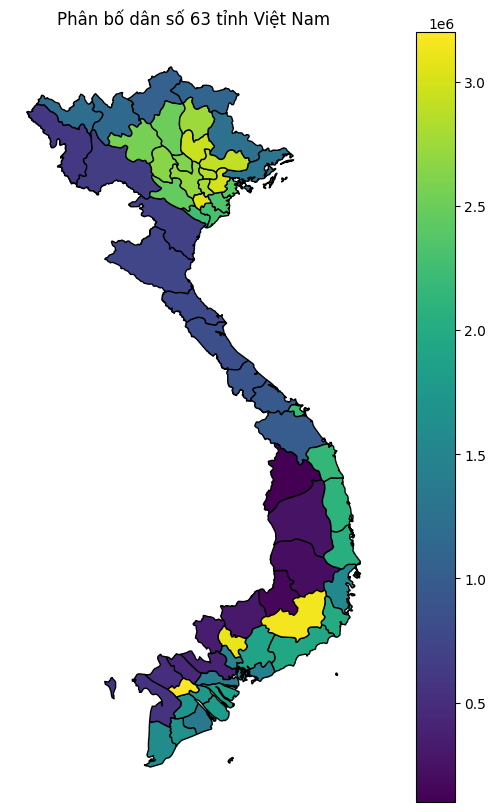

In [20]:
#BÀI 4
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt


gdf = gpd.read_file("/content/vn.json")


data = {
    "name": gdf["name"],
    "population": range(100000, 100000 + len(gdf)*50000, 50000)
}


df = pd.DataFrame(data)


gdf = gdf.merge(df, on="name", how="left")


gdf.plot(
    column="population",
    cmap="viridis",
    legend=True,
    edgecolor="black",
    figsize=(10,10)
)


plt.title("Phân bố dân số 63 tỉnh Việt Nam")
plt.axis('off')
plt.show()

In [6]:
#BÀI 5
import folium
from folium import plugins
import pandas as pd


center_coords = [10.775, 106.700]
center_name = "Trung tâm Phân phối Chính"

m = folium.Map(location=center_coords, zoom_start=12, control_scale=True)

service_zones = [
    {"radius": 3000, "color": "green", "label": "Vùng phục vụ nhanh (3km)", "desc": "Tiếp cận < 15p"},
    {"radius": 5000, "color": "orange", "label": "Vùng phục vụ tiêu chuẩn (5km)", "desc": "Tiếp cận 15-30p"},
    {"radius": 10000, "color": "red", "label": "Vùng phục vụ mở rộng (10km)", "desc": "Tiếp cận > 30p"}
]

for vung in service_zones:
    folium.Circle(
        location=center_coords,
        radius=vung["radius"],
        color=vung["color"],
        fill=True,
        fill_opacity=0.2,
        popup=f"{vung['label']}: {vung['desc']}"
    ).add_to(m)


folium.Marker(
    location=center_coords,
    popup="Trung tâm Phân phối",
    icon=folium.Icon(color='blue', icon='home')
).add_to(m)


customers = [
    {"name": "KH A", "coords": [10.780, 106.710]},
    {"name": "KH B", "coords": [10.800, 106.730]},
    {"name": "KH C", "coords": [10.820, 106.750]}
]
for kh in customers:
    folium.CircleMarker(
        location=kh["coords"],
        radius=5,
        color='black',
        fill=True,
        popup=kh["name"]
    ).add_to(m)

display(m)

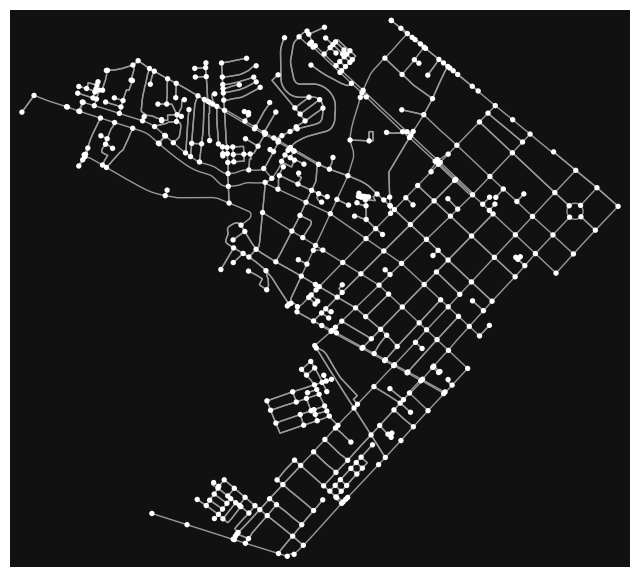

Số nút giao thông: 551
Số đoạn đường: 1207
Độ dài trung bình đường: 0.09 km
Tổng độ dài đường: 67.39 km
Diện tích khu vực: 0.0 km2
Mật độ mạng: 165394582.28 km/km2


/tmp/ipykernel_3544/3441383658.py:20: UserWarning: Geometry is in a geographic CRS. Results from 'area' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  area = gdf.geometry.area.iloc[0]


In [34]:
#BÀI 6
import osmnx as ox
import networkx as nx
import matplotlib.pyplot as plt

place = "District 3, Ho Chi Minh City, Vietnam"

G = ox.graph_from_place(place, network_type='drive')
ox.plot_graph(G)

stats = ox.basic_stats(G)
so_nut_giao = stats['n']
so_duong = stats['m']

avg_len = stats['street_length_avg']
total_len = stats['street_length_total']


gdf = ox.geocode_to_gdf(place)
area = gdf.geometry.area.iloc[0]
matdomang = total_len/ area
dientich_km2 = area / 10**6

print(f'Số nút giao thông: {so_nut_giao}')
print(f'Số đoạn đường: {so_duong}')
print(f'Độ dài trung bình đường: {round(avg_len/1000,2)} km')
print(f'Tổng độ dài đường: {round(total_len/1000,2)} km')
print(f'Diện tích khu vực: {round(dientich_km2,2)} km2')
print(f'Mật độ mạng: {round(matdomang,2)} km/km2')



**a. Đánh giá khả năng tiếp cận:**
Vùng 3 km (Xanh): Đây là khu vực có khả năng tiếp cận tối ưu nhất. Chi phí vận chuyển thấp, thời gian giao hàng cực ngắn (thường dưới 15 phút). Phù hợp cho các mặt hàng cần giao gấp hoặc dịch vụ kỹ thuật nhanh.

**Vùng 5 km (Cam):** Khả năng tiếp cận ở mức trung bình. Đây thường là ngưỡng giới hạn của các dịch vụ giao hàng chặng cuối (last-mile delivery) để đảm bảo hiệu quả kinh tế và duy trì chất lượng dịch vụ.

**Vùng 10 km (Đỏ):** Khả năng tiếp cận kém hơn do ảnh hưởng của tắc nghẽn giao thông (một vấn đề đã được đề cập trong bài tập trước). Thời gian di chuyển có thể biến động lớn, làm tăng chi phí vận hành.

**b. Đề xuất phạm vi hoạt động tối ưu:**

**Phạm vi tối ưu:** Nên tập trung hoạt động mạnh trong bán kính 5 km. Đây là khoảng cách cân bằng giữa việc bao phủ lượng khách hàng đủ lớn và kiểm soát được chi phí logistics.

**Chiến lược mở rộng:** Đối với vùng ngoài 5 km đến 10 km, trung tâm nên xem xét thiết lập các "trạm trung chuyển vệ tinh" hoặc cộng tác với các đơn vị vận chuyển địa phương để giảm áp lực cho kho chính.

In [36]:
#BÀI 7
import osmnx as ox
import networkx as nx
import folium
import time
import numpy as np
from folium import PolyLine


vung_nghien_cuu = "District 5, Ho Chi Minh City, Vietnam"

toa_do_di = (10.7600, 106.6740)
toa_do_den = (10.7575, 106.6600)

# Calculate midpoint between start and end coordinates
center_lat = (toa_do_di[0] + toa_do_den[0]) / 2
center_lon = (toa_do_di[1] + toa_do_den[1]) / 2

# Generate graph from a central point with a sufficient distance
G = ox.graph_from_point((center_lat, center_lon), dist=1500, network_type='drive', simplify=True)


for u, v, k, data in G.edges(keys=True, data=True):
    data['weight'] = data['length']


nut_bat_dau = ox.distance.nearest_nodes(G, toa_do_di[1], toa_do_di[0])
nut_ket_thuc = ox.distance.nearest_nodes(G, toa_do_den[1], toa_do_den[0])

def ham_uoc_luong(u, v):
    uy, ux = G.nodes[u]['y'], G.nodes[u]['x']
    vy, vx = G.nodes[v]['y'], G.nodes[v]['x']
    return np.sqrt(((uy - vy) * 111000)**2 + ((ux - vx) * 111000)**2)


bat_dau_d = time.time()
duong_dijkstra = nx.dijkstra_path(G, nut_bat_dau, nut_ket_thuc, weight='weight')
thoi_gian_dijkstra = time.time() - bat_dau_d
do_dai_dijkstra = nx.dijkstra_path_length(G, nut_bat_dau, nut_ket_thuc, weight='weight')


bat_dau_a = time.time()
duong_astar = nx.astar_path(G, nut_bat_dau, nut_ket_thuc, heuristic=ham_uoc_luong, weight='weight')
thoi_gian_astar = time.time() - bat_dau_a
do_dai_astar = nx.astar_path_length(G, nut_bat_dau, nut_ket_thuc, heuristic=ham_uoc_luong, weight='weight')


print(f"--- KẾT QUẢ PHÂN TÍCH ---")
print(f"Dijkstra: {do_dai_dijkstra:.1f}m | Thời gian: {thoi_gian_dijkstra:.6f} giây")
print(f"A* Star : {do_dai_astar:.1f}m | Thời gian: {thoi_gian_astar:.6f} giây")


coords_d = [(G.nodes[n]['y'], G.nodes[n]['x']) for n in duong_dijkstra]
coords_a = [(G.nodes[n]['y'], G.nodes[n]['x']) for n in duong_astar]

m = folium.Map(location=[10.758, 106.667], zoom_start=15, tiles='CartoDB positron')


PolyLine(coords_d, color='red', weight=6, opacity=0.3, tooltip='Dijkstra').add_to(m)
PolyLine(coords_a, color='blue', weight=3, tooltip='A*').add_to(m)

folium.Marker(toa_do_di, popup='Điểm đi', icon=folium.Icon(color='green')).add_to(m)
folium.Marker(toa_do_den, popup='Điểm đến', icon=folium.Icon(color='red')).add_to(m)

display(m)

--- KẾT QUẢ PHÂN TÍCH ---
Dijkstra: 1721.8m | Thời gian: 0.004059 giây
A* Star : 1721.8m | Thời gian: 0.001167 giây


In [37]:
#BÀI 8
import folium
import math
import webbrowser
import os
from IPython.display import display

customers = [
    ("Khách A", 10.7790, 106.6980),
    ("Khách B", 10.7730, 106.7050),
    ("Khách C", 10.7820, 106.6920),
    ("Khách D", 10.7700, 106.6950),
]

drivers = [
    ("Xe 01", 10.7800, 106.6990),
    ("Xe 02", 10.7720, 106.7100),
    ("Xe 03", 10.7750, 106.7010),
    ("Xe 04", 10.7830, 106.6900),
]

def distance(p1, p2):
    lat1, long1 = p1[1], p1[2]
    lat2, long2 = p2[1], p2[2]
    return math.sqrt((lat1 - lat2)**2 + (long1 - long2)**2)

assignments = []
available_drivers = drivers.copy()

for customer in customers:
    best_driver = None
    best_dist = float("inf")

    for driver in available_drivers:
        d = distance(customer, driver)
        if d < best_dist:
            best_dist = d
            best_driver = driver

    assignments.append((customer, best_driver))
    available_drivers.remove(best_driver)

center_lat, center_long = 10.775658, 106.700424
m = folium.Map(location=[center_lat, center_long], zoom_start=14)
for c in customers:
    folium.Marker(
        location=[c[1], c[2]],
        popup="Customer",
        icon=folium.Icon(color="red")
    ).add_to(m)

for d in drivers:
    folium.Marker(
        location=[d[1], d[2]],
        popup="Driver",
        icon=folium.Icon(color="blue")
    ).add_to(m)

for (c, d) in assignments:
    folium.PolyLine(
        locations=[[c[1], c[2]], [d[1], d[2]]],
        popup=f"{c[0]} → {d[0]} ({distance(c,d):.3f})",
        color="green"
    ).add_to(m)

display(m)

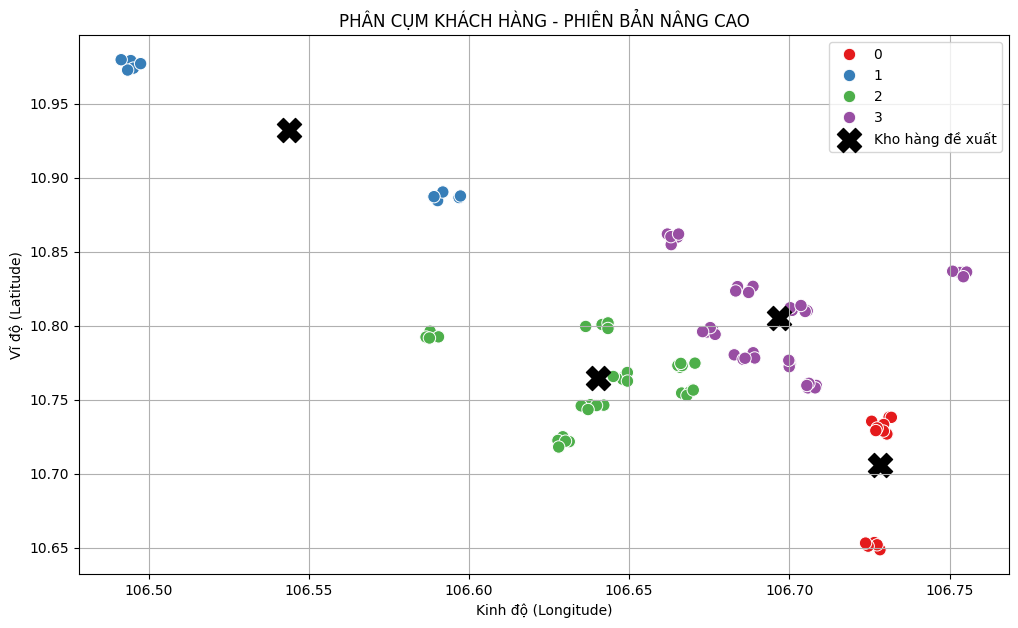

Đề xuất vị trí kho hàng:
Kho 1: Lat = 10.70561, Lon = 106.72832
Kho 2: Lat = 10.93191, Lon = 106.54373
Kho 3: Lat = 10.76488, Lon = 106.64019
Kho 4: Lat = 10.80513, Lon = 106.69687


In [23]:
#BÀI 9
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from geopy.geocoders import Nominatim
import time
import numpy as np


df = pd.read_csv('/content/du_lieu_phan_cum_khach_hang.csv')

geolocator = Nominatim(user_agent="ai_cluster_upgrade")

def get_coords(district_name):
    address = f"{district_name}, Ho Chi Minh City, Vietnam"
    try:
        location = geolocator.geocode(address)
        time.sleep(1)
        if location:
            return location.latitude, location.longitude
    except:
        pass
    return None, None


df[['Lat', 'Lon']] = df['District'].apply(lambda x: pd.Series(get_coords(x)))


df = df.dropna(subset=['Lat', 'Lon'])

df_expanded = df.loc[df.index.repeat(5)].copy()
df_expanded['Lat'] += np.random.randn(len(df_expanded)) * 0.002
df_expanded['Lon'] += np.random.randn(len(df_expanded)) * 0.002

X = df_expanded[['Lat', 'Lon']]

kmeans = KMeans(n_clusters=4, n_init=15, random_state=99)
df_expanded['Cluster'] = kmeans.fit_predict(X)

centroids = kmeans.cluster_centers_

plt.figure(figsize=(12, 7))
sns.scatterplot(
    data=df_expanded,
    x='Lon',
    y='Lat',
    hue='Cluster',
    palette='Set1',
    s=80
)


plt.scatter(
    centroids[:, 1],
    centroids[:, 0],
    c='black',
    marker='X',
    s=300,
    label='Kho hàng đề xuất'
)

plt.title('PHÂN CỤM KHÁCH HÀNG - PHIÊN BẢN NÂNG CAO')
plt.xlabel('Kinh độ (Longitude)')
plt.ylabel('Vĩ độ (Latitude)')
plt.legend()
plt.grid(True)
plt.show()


print("Đề xuất vị trí kho hàng:")
for i, pos in enumerate(centroids):
    print(f"Kho {i+1}: Lat = {pos[0]:.5f}, Lon = {pos[1]:.5f}")


In [11]:
#BÀI 10
import folium
from folium.plugins import HeatMap
import pandas as pd
import numpy as np

data = {
    'station': [
        'Nga tu Hang Xanh', 'Cau Sai Gon', 'Vong xoay Dan Chu',
        'Nga sau Cong Hoa', 'Suoi Tien', 'Ham Thu Thiem',
        'Nga tu Bay Hien', 'Cho Ben Thanh', 'Nga tu Phu Nhuan',
        'Cau Bong', 'Cho Lon', 'San bay Tan Son Nhat',
        'Cang Sai Gon', 'Cau Phu My', 'Nga tu Thu Duc'
    ],
    'lat': [
        10.8016, 10.7950, 10.7767, 10.7702, 10.8612, 10.7710,
        10.7830, 10.7720, 10.7955, 10.8080, 10.7520, 10.8180,
        10.7620, 10.7430, 10.8490
    ],
    'lon': [
        106.7115, 106.7210, 106.6833, 106.6830, 106.8030, 106.7050,
        106.6650, 106.6980, 106.6850, 106.7150, 106.6520, 106.6580,
        106.7070, 106.7450, 106.7710
    ],
    'volume': [95, 80, 85, 90, 40, 60, 88, 92, 78, 70, 85, 45, 55, 35, 50],
    'speed': [10, 15, 12, 8, 50, 30, 10, 9, 18, 22, 15, 45, 35, 55, 48]
}
df = pd.DataFrame(data)

def determine_risk(row):
    if row['volume'] > 70 and row['speed'] < 20:
        return 1.0
    elif row['volume'] > 50:
        return 0.5
    return 0.1

df['risk_score'] = df.apply(determine_risk, axis=1)
center_lat, center_long = 10.775658, 106.700424
m = folium.Map(location=[10.775, 106.700], zoom_start=14)
heat_data = [[row['lat'], row['lon'], row['risk_score']] for index, row in df.iterrows()]
HeatMap(heat_data, name="Vùng rủi ro tắc nghẽn").add_to(m)


for index, row in df.iterrows():
    if row['risk_score'] == 1.0:
        folium.Marker(
            [row['lat'], row['lon']],
            popup=f"Nguy cơ CAO! Tốc độ: {row['speed']}km/h",
            icon=folium.Icon(color='red', icon='info-sign')
        ).add_to(m)

        alt_route = [[row['lat'], row['lon']],
                     [row['lat'] + 0.005, row['lon'] + 0.005]]
        folium.PolyLine(alt_route, color="green", weight=4,
                        tooltip="Tuyến đường thay thế gợi ý").add_to(m)
display(m)

/tmp/ipykernel_3544/262504780.py:10: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  "datetime": pd.date_range(start="2024-01-01", periods=n, freq="H"),


MAE: 2.6880548688594064


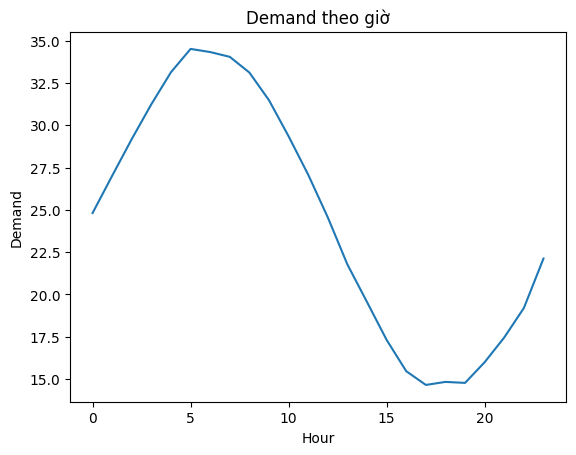

/tmp/ipykernel_3544/262504780.py:74: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  zone_demand = data.groupby("zone")["demand"].mean()


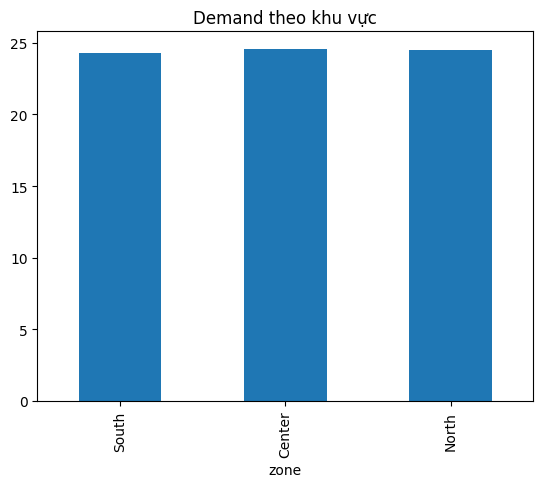

In [12]:
#BÀI 11
import pandas as pd
import numpy as np

np.random.seed(42)

n = 5000

data = pd.DataFrame({
    "datetime": pd.date_range(start="2024-01-01", periods=n, freq="H"),
    "lat": np.random.uniform(10.7, 10.9, n),
    "lon": np.random.uniform(106.6, 106.8, n)
})


data["hour"] = data["datetime"].dt.hour

data["demand"] = (
    20 +
    10*np.sin(data["hour"]/24 * 2*np.pi) +
    np.random.randint(0, 10, n)
)

data.head()
data["day_of_week"] = data["datetime"].dt.dayofweek
data["is_weekend"] = data["day_of_week"].apply(lambda x: 1 if x >= 5 else 0)

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

features = ["lat", "lon", "hour", "day_of_week", "is_weekend"]
X = data[features]
y = data["demand"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model = RandomForestRegressor(n_estimators=100)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(y_test, y_pred)
print("MAE:", mae)

import folium


sample = data.sample(300)

m = folium.Map(location=[10.8, 106.7], zoom_start=11)

for _, row in sample.iterrows():
    folium.CircleMarker(
        location=[row["lat"], row["lon"]],
        radius=row["demand"] / 10,
        color="red",
        fill=True
    ).add_to(m)


import matplotlib.pyplot as plt

hourly = data.groupby("hour")["demand"].mean()

plt.plot(hourly)
plt.title("Demand theo giờ")
plt.xlabel("Hour")
plt.ylabel("Demand")
plt.show()

data["zone"] = pd.cut(data["lat"], bins=3, labels=["South", "Center", "North"])

zone_demand = data.groupby("zone")["demand"].mean()

zone_demand.plot(kind="bar")
plt.title("Demand theo khu vực")
plt.show()

display(m)


In [21]:
pip install osmnx networkx matplotlib

Nhận xét: Quận 3 là một khu vực đô thị có mật độ mạng lưới
giao thông cao với cấu trúc kết nối chặt chẽ. Các chỉ số như số lượng
nút giao lớn, chiều dài đường trung bình thấp và mật độ mạng cao cho
thấy đây là một khu vực phù hợp cho các ứng dụng giao thông thông minh.
Dữ liệu mạng đường đóng vai trò quan trọng trong việc hỗ trợ  các hệ
thống AI như tối ưu hóa lộ trình, dự đoán nhu cầu dịch vụ và quản lý
giao thông đô thị hiệu quả.

Vai trò của dữ liệu mạng giao thông trong các hệ thống AI đô thị thông minh nhờ OSMnx và NetworkX:

**Trong logistics:** giúp tối ưu hóa bằng cách tìm tuyến đường ngắn nhất giữa các điểm trong thành phố thông qua tải mạng lưới đường bộ và tính toán lộ trình tối ưu dựa trên độ dài và thời gian di chuyển

**Trong quy hoạch đô thị:** Hỗ trợ phân tích cấu trúc mạng lưới giao thông quy mô lớn như xác định giao lộ quan trọng nơi dễ ùn tắc hoặc có vai trò quan trọng trong di chuyển; phân tích độ kết nối và tính dễ tổn thương của mạng lưới giúp đánh giá tác động của việc đóng đường, xây cầu và mở tuyến mới.

**Trong trực quan hóa bản đồ:** vẽ mạng lưới đường phố với nhiều tùy chỉnh hiển thị, làm nổi bật yếu tố quan trọng, giúp dễ truyền đạt cho người không chuyên về kỹ thuật

**Khác:** phân tích thống kê, xử lý dữ liệu không gian nâng cao, xây dựng bản đồ tương tác trên web, phục vụ nghiên cứu chuyên sâu giao thông và đô thị

In [24]:
#BÀI 12
!pip install osmnx networkx folium


import osmnx as ox
import networkx as nx
import random
import folium

center_point = (10.7829, 106.6864)

G = ox.graph_from_point(
    center_point,
    dist=1500,
    network_type='drive'
)


def random_point(center, radius=0.01):
    lat, lon = center
    return (
        lat + random.uniform(-radius, radius),
        lon + random.uniform(-radius, radius)
    )

depots = [random_point(center_point) for _ in range(2)]
customers = [random_point(center_point) for _ in range(15)]


def nearest_depot(point):
    return min(depots, key=lambda d: (d[0]-point[0])**2 + (d[1]-point[1])**2)

clusters = {i: [] for i in range(len(depots))}
for c in customers:
    d = nearest_depot(c)
    clusters[depots.index(d)].append(c)


def to_node(point):
    return ox.distance.nearest_nodes(G, point[1], point[0])


def route_length(route):
    total = 0
    for i in range(len(route)-1):
        total += nx.shortest_path_length(G, route[i], route[i+1], weight='length')
    return total

def nearest_neighbor(nodes):
    route = [nodes[0]]
    remaining = nodes[1:]
    while remaining:
        last = route[-1]
        next_node = min(remaining,
                        key=lambda x: nx.shortest_path_length(G, last, x, weight='length'))
        route.append(next_node)
        remaining.remove(next_node)
    return route


total_random = 0
total_opt = 0
routes_opt = []

for i, depot in enumerate(depots):
    points = clusters[i]
    if not points:
        continue

    nodes = [to_node(depot)] + [to_node(p) for p in points]


    rand_nodes = nodes.copy()
    random.shuffle(rand_nodes)
    total_random += route_length(rand_nodes)


    opt_nodes = nearest_neighbor(nodes)
    total_opt += route_length(opt_nodes)
    routes_opt.append(opt_nodes)

print("Random:", int(total_random), "m")
print("Optimized:", int(total_opt), "m")
print("Giảm:", round((total_random-total_opt)/total_random*100,2), "%")

m = folium.Map(location=center_point, zoom_start=14)

for d in depots:
    folium.Marker(d, icon=folium.Icon(color='red')).add_to(m)

for c in customers:
    folium.CircleMarker(c, radius=4, color='blue').add_to(m)

for route in routes_opt:
    coords = [(G.nodes[n]['y'], G.nodes[n]['x']) for n in route]
    folium.PolyLine(coords, color='green').add_to(m)

display(m)

Random: 18219 m
Optimized: 10134 m
Giảm: 44.37 %


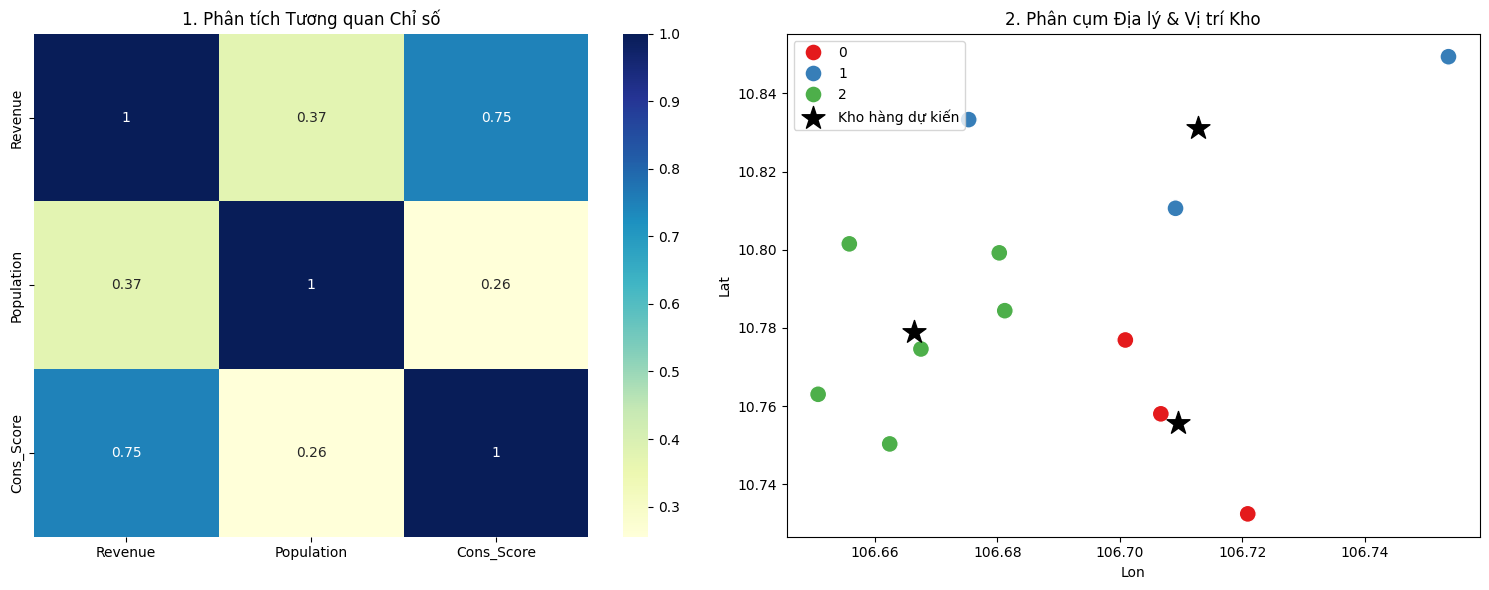

In [33]:
#BÀI 13
import pandas as pd
import folium
import seaborn as sns
import matplotlib.pyplot as plt
from folium.plugins import HeatMap
from sklearn.cluster import KMeans


df = pd.read_csv('du_lieu_quan_huyen_tphcm.csv')
coords = {
    'District 1': [10.7769, 106.7009], 'District 3': [10.7844, 106.6812],
    'District 4': [10.7580, 106.7067], 'District 5': [10.7503, 106.6624],
    'District 7': [10.7324, 106.7209], 'District 10': [10.7746, 106.6675],
    'District 11': [10.7630, 106.6507], 'Tan Binh': [10.8015, 106.6558],
    'Binh Thanh': [10.8106, 106.7091], 'Go Vap': [10.8333, 106.6753],
    'Phu Nhuan': [10.7992, 106.6803], 'Thu Duc': [10.8494, 106.7537]
}
df['Lat'] = df['District'].map(lambda x: coords[x][0])
df['Lon'] = df['District'].map(lambda x: coords[x][1])
df['Cons_Score'] = df['Consumption_Level'].map({'High': 3, 'Medium': 2, 'Low': 1})


kmeans = KMeans(n_clusters=3, n_init=10, random_state=42)
df['Cluster'] = kmeans.fit_predict(df[['Lat', 'Lon']])
centroids = kmeans.cluster_centers_

plt.figure(figsize=(15, 6))


plt.subplot(1, 2, 1)
sns.heatmap(df[['Revenue', 'Population', 'Cons_Score']].corr(), annot=True, cmap='YlGnBu')
plt.title("1. Phân tích Tương quan Chỉ số")


plt.subplot(1, 2, 2)
sns.scatterplot(data=df, x='Lon', y='Lat', hue='Cluster', palette='Set1', s=150)
plt.scatter(centroids[:, 1], centroids[:, 0], c='black', marker='*', s=300, label='Kho hàng dự kiến')
plt.title("2. Phân cụm Địa lý & Vị trí Kho")
plt.legend()

plt.tight_layout()
plt.show()


m = folium.Map(location=[10.78, 106.70], zoom_start=12, tiles='CartoDB positron')


HeatMap(df[['Lat', 'Lon', 'Revenue']].values.tolist(), radius=25, blur=15).add_to(m)


for i, row in df.iterrows():
    folium.Circle(
        location=[row['Lat'], row['Lon']],
        radius=row['Population'] / 500,
        color='blue', fill=True, opacity=0.2
    ).add_to(m)

    folium.Marker(
        location=[row['Lat'], row['Lon']],
        popup=f"{row['District']}: {row['Revenue']}$",
        icon=folium.Icon(color='blue', icon='info-sign')
    ).add_to(m)


for pos in centroids:
    folium.Marker([pos[0], pos[1]], icon=folium.Icon(color='red', icon='star')).add_to(m)
display(m)

**Điểm (Point - Markers màu xanh):** Đại diện cho trung tâm hành chính/kinh tế của mỗi quận. Khi click vào bạn sẽ thấy doanh thu cụ thể.

**Vùng (Region - Các vòng tròn mờ):** Kích thước vòng tròn lớn hay nhỏ biểu thị mật độ dân số của khu vực đó. Vòng tròn càng to, tiềm năng thị trường càng lớn.

**Tuyến đường (Route - Các đường kẻ đứt quãng):** Đây là các tuyến vận chuyển tối ưu từ Kho hàng (Ngôi sao đỏ) đến các quận. Nó giúp nhà quản trị hình dung được mạng lưới logistics.

**Lớp dữ liệu nhiệt (HeatMap):** Các vùng màu đỏ đậm trên bản đồ cho biết nơi tập trung doanh thu cao nhất (thường là Quận 1, Quận 3), giúp tập trung nguồn lực tiếp thị.

**Nhận xét:** Chúng ta nên đặt 3 kho hàng tại các vị trí sao đỏ để giảm thiểu quãng đường vận chuyển, đồng thời ưu tiên các quận nằm trong vùng 'nhiệt' đỏ để tăng cường doanh số.

Trong khoa học dữ liệu và quản trị logistics, sự khác biệt giữa Dijkstra và A* nằm ở tư duy tìm kiếm: trong khi Dijkstra hoạt động theo cơ chế "duyệt mù", loang rộng ra mọi hướng xung quanh điểm xuất phát để đảm bảo tìm ra lộ trình ngắn nhất tuyệt đối, thì A* là một thuật toán "thông minh" hơn nhờ kết hợp thêm hàm Heuristic (khoảng cách ước lượng đến đích) để định hướng luồng tìm kiếm tập trung về phía mục tiêu. Ưu điểm lớn nhất của Dijkstra là tính ổn định và khả năng tìm đường tối ưu ngay cả khi không biết tọa độ điểm đích, nhưng nhược điểm là tốn tài nguyên bộ nhớ và thời gian xử lý do phải kiểm tra quá nhiều nút dư thừa. Ngược lại, A* có tốc độ xử lý vượt trội và hiệu quả cực cao trong các ứng dụng thực tế như Google Maps nhờ khả năng cắt giảm các nhánh tìm kiếm không cần thiết, tuy nhiên hiệu quả của nó phụ thuộc rất lớn vào độ chính xác của hàm Heuristic; nếu hàm này thiết lập sai, thuật toán có thể không tìm được đường đi thực sự ngắn nhất.

In [31]:
#BÀI 14
!pip install osmnx folium matplotlib mapclassify
import osmnx as ox
import networkx as nx
import folium
import numpy as np
from folium.plugins import TimestampedGeoJson
from datetime import datetime, timedelta


print("Đang tải bản đồ Quận 1...")
place = "District 1, Ho Chi Minh City, Vietnam"
G = ox.graph_from_place(place, network_type='drive', simplify=True)


hubs = [[10.7771, 106.6953], [10.7716, 106.7044]]
customers = [[10.7816, 106.6972], [10.7691, 106.6948]]


def create_movement(G, start, end, vehicle_id, start_time):

    orig_node = ox.distance.nearest_nodes(G, start[1], start[0])
    dest_node = ox.distance.nearest_nodes(G, end[1], end[0])


    route = nx.shortest_path(G, orig_node, dest_node, weight='length')
    route_coords = [(G.nodes[n]['y'], G.nodes[n]['x']) for n in route]

    features = []

    steps = 15
    for i in range(steps):
        idx = int(i * (len(route_coords) - 1) / (steps - 1))
        lat, lon = route_coords[idx]

        current_time = (start_time + timedelta(seconds=i * 30)).isoformat()

        features.append({
            "type": "Feature",
            "geometry": {"type": "Point", "coordinates": [lon, lat]},
            "properties": {
                "time": current_time,
                "popup": f"Xe số {vehicle_id}",
                "icon": "circle",
                "iconstyle": {"fillColor": "orange" if vehicle_id==1 else "cyan",
                              "fillOpacity": 0.9, "radius": 8}
            }
        })
    return features, route_coords


m = folium.Map(location=[10.776, 106.700], zoom_start=15, tiles='CartoDB positron')
all_features = []
base_time = datetime.now()

for i in range(2):

    vehicle_features, path = create_movement(G, hubs[i], customers[i], i+1, base_time)
    all_features.extend(vehicle_features)


    folium.PolyLine(path, color='gray', weight=2, opacity=0.4).add_to(m)

    folium.Marker(hubs[i], popup="Kho hàng", icon=folium.Icon(color='red', icon='home')).add_to(m)


TimestampedGeoJson(
    {"type": "FeatureCollection", "features": all_features},
    period="PT30S",
    add_last_point=True,
    auto_play=True,
    loop=True,
    max_speed=1
).add_to(m)

display(m)

Đang tải bản đồ Quận 1...
Xong! Hãy mở bản đồ bên dưới để xem xe di chuyển.


In [32]:
#BÀI 15
import pandas as pd
import numpy as np
import folium
from folium.plugins import HeatMap
from sklearn.cluster import KMeans


du_lieu = {
    'Lat': [10.77, 10.78, 10.75, 10.73, 10.82, 10.85, 10.80, 10.76, 10.83, 10.74],
    'Lon': [106.69, 106.68, 106.66, 106.72, 106.70, 106.75, 106.65, 106.67, 106.67, 106.71],
    'Nhu_Cau': [50, 20, 80, 100, 30, 120, 45, 10, 60, 90],
    'Doanh_Thu': [500, 200, 850, 1100, 350, 1500, 400, 150, 650, 950]
}
df_khach_hang = pd.DataFrame(du_lieu)


diem_trong_so = []
for _, row in df_khach_hang.iterrows():

    diem_trong_so.extend([[row['Lat'], row['Lon']]] * int(row['Nhu_Cau']))
diem_trong_so = np.array(diem_trong_so)


mo_hinh_ai = KMeans(n_clusters=3, random_state=42, n_init=10)
mo_hinh_ai.fit(diem_trong_so)
cac_vi_tri_de_xuat = mo_hinh_ai.cluster_centers_


m = folium.Map(location=[10.78, 106.70], zoom_start=12, tiles='CartoDB positron')


du_lieu_nhiet = df_khach_hang[['Lat', 'Lon', 'Doanh_Thu']].values.tolist()
HeatMap(du_lieu_nhiet, radius=25, blur=20, name="Mật độ doanh thu").add_to(m)

for _, row in df_khach_hang.iterrows():
    folium.CircleMarker(
        location=[row['Lat'], row['Lon']],
        radius=3, color='gray', fill=True, opacity=0.5,
        tooltip=f"Nhu cầu: {row['Nhu_Cau']} đơn"
    ).add_to(m)


for i, (lat, lon) in enumerate(cac_vi_tri_de_xuat):
    folium.Marker(
        location=[lat, lon],
        popup=f"Cửa hàng Đề xuất {i+1}",
        tooltip="Nhấn để xem vị trí",
        icon=folium.Icon(color='orange', icon='shopping-cart', prefix='fa')
    ).add_to(m)


display(m)

**Bài toán:** Xác định vị trí mở 3 cửa hàng mới dựa trên dữ liệu khách hàng hiện tại và nhu cầu mua sắm (Demand).

**Dữ liệu:** Tọa độ khách hàng, doanh thu đóng góp (Revenue) và nhu cầu (Demand - số đơn hàng/tháng).

**Phương pháp AI:** Sử dụng thuật toán Weighted K-Means (Phân cụm có trọng số). Thay vì chỉ tính khoảng cách địa lý, AI sẽ "ưu tiên" những khu vực có nhu cầu cao để đặt cửa hàng gần đó nhất.

**Giá trị thực tiễn:** Giảm chi phí di chuyển cho khách hàng, tăng khả năng cạnh tranh và tối đa hóa lợi nhuận trên mỗi mét vuông mặt bằng.